## YOLO11n Object Detection

## Task 1 – Multi-Object Detection with Pre-trained YOLO11n
---

### Objective
---

The objective of this project is to perform advanced object detection using the YOLO11n model.

Task 1 involves running inference on a set of test images using the pre-trained YOLO11n model to see how it performs out of the box.
Task 2 focuses on fine-tuning the model on a custom signature dataset to detect handwritten signatures, validating its performance, and comparing the detection results of the last and best trained epoch models.

---

#### 1. Setup and Initialization
---

In [ ]:
%pip install -q torch timm ultralytics albumentations

from google.colab import drive
drive.mount('/content/drive')

from ultralytics import YOLO

model = YOLO("yolo11n.pt")

---
#### 2. Multi-Object Detection with Pre-trained YOLO11n
---

Multi-Object Detection Explanation:-

The pre-trained YOLO11n model runs inference on 5 selected test images to visually evaluate the performance of out-of-the-box object detection.

Since the base model has been trained on the COCO dataset, it can detect common objects such as people, dogs, and chairs.
The `result.plot()` method handles rendering the annotated image via matplotlib, visualizing the detected items with bounding boxes, class labels, and confidence scores across the original test images.

---


,Results for PeopleDog.jpg:
,
,image 1/1 /content/drive/MyDrive/Colab Notebooks/test_images/PeopleDog.jpg: 448x640 1 person, 1 dog, 49.2ms
,Speed: 11.7ms preprocess, 49.2ms inference, 42.2ms postprocess per image at shape (1, 3, 448, 640)


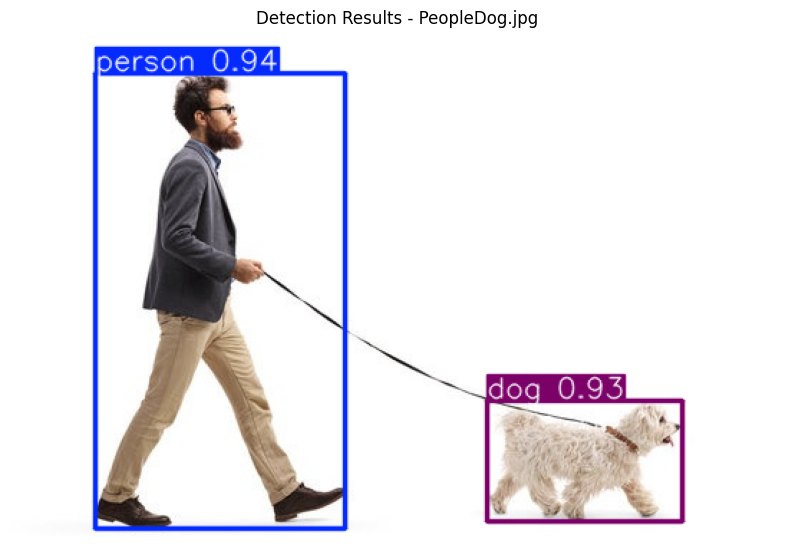


,Results for PeopleDogs2.jpg:
,
,image 1/1 /content/drive/MyDrive/Colab Notebooks/test_images/PeopleDogs2.jpg: 640x416 1 person, 2 dogs, 60.7ms
,Speed: 2.6ms preprocess, 60.7ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 416)


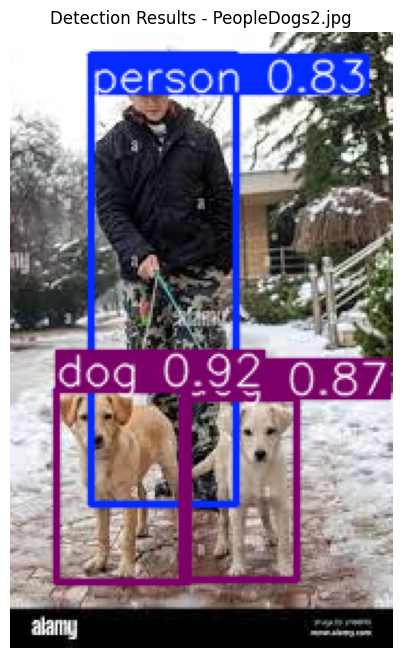


,Results for TableSofa.jpg:
,
,image 1/1 /content/drive/MyDrive/Colab Notebooks/test_images/TableSofa.jpg: 640x640 2 couchs, 2 potted plants, 1 book, 1 vase, 12.4ms
,Speed: 3.5ms preprocess, 12.4ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


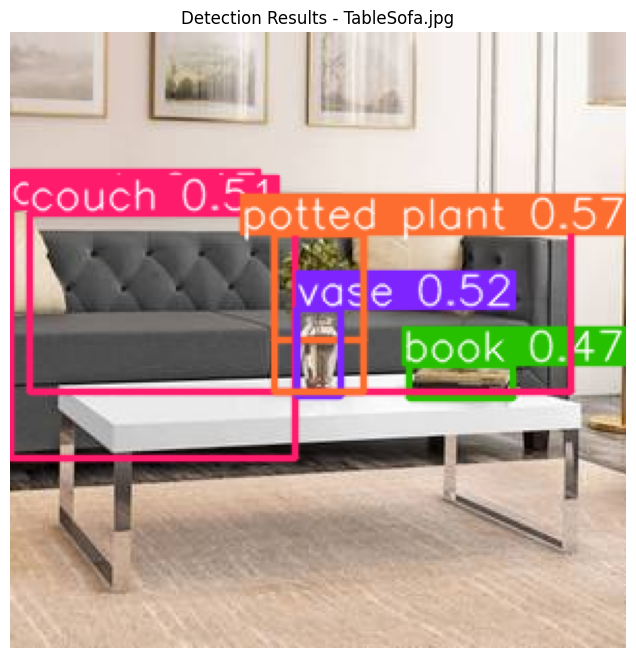


,Results for TableChairs4.jpg:
,
,image 1/1 /content/drive/MyDrive/Colab Notebooks/test_images/TableChairs4.jpg: 608x640 4 chairs, 1 potted plant, 1 dining table, 1 book, 71.6ms
,Speed: 4.9ms preprocess, 71.6ms inference, 1.3ms postprocess per image at shape (1, 3, 608, 640)


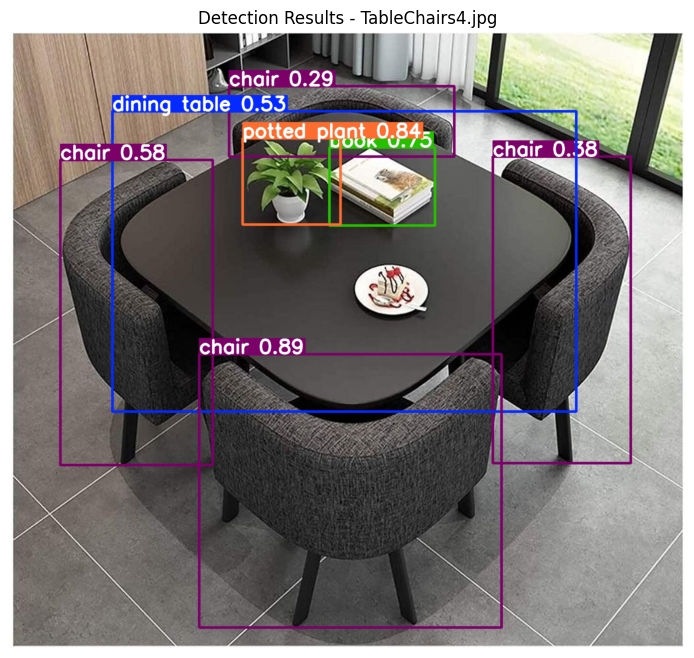


,Results for Signatures.jpg:
,
,image 1/1 /content/drive/MyDrive/Colab Notebooks/test_images/Signatures.jpg: 640x640 1 scissors, 11.4ms
,Speed: 6.7ms preprocess, 11.4ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


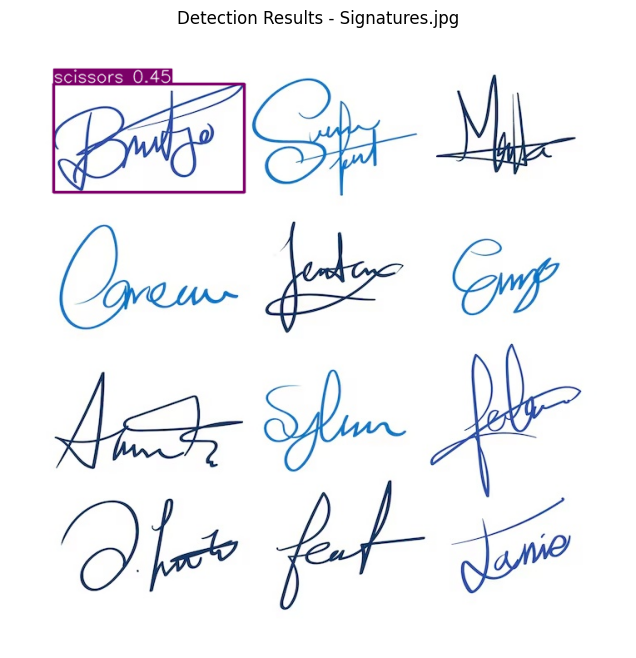

In [10]:
import matplotlib.pyplot as plt
import cv2
import os

image_dir = '/content/drive/MyDrive/Colab Notebooks/test_images/'

original_image_names = ['PeopleDog.jpg', 'PeopleDogs2.jpg', 'TableSofa.jpg', 'TableChairs4.jpg', 'Signatures.jpg']

test_images = [os.path.join(image_dir, img_name) for img_name in original_image_names]

for img_path in test_images:
    if not os.path.exists(img_path):
        print(f"Error: Image not found at {img_path}. Please ensure it's in your Google Drive.")
        continue

    print(f"\nResults for {os.path.basename(img_path)}:")
    results = model(img_path)

    for result in results:
        res_img = result.plot()

        plt.figure(figsize=(10, 8))
        plt.imshow(cv2.cvtColor(res_img, cv2.COLOR_BGR2RGB))
        plt.title(f"Detection Results - {os.path.basename(img_path)}")
        plt.axis('off')
        plt.show()

---
### Observations on Detection Results

---

The pre-trained YOLO11n model accurately detected multiple objects like people, dogs, tables, and chairs in the regular images.

However, the model struggles heavily with handwritten signatures because "signatures" are not part of the standard COCO dataset categories the YOLO11n base model was trained on.
To solve this issue, fine-tuning the model on a specific signature dataset is required to teach it this custom class.

---

## Task 2 – Fine-Tuning YOLO11n for Signature Detection
---

#### 1. Downloading and Preparing the Dataset
---

In [11]:
!wget https://github.com/ultralytics/assets/releases/download/v0.0.0/signature.zip
!unzip -q signature.zip -d .
!wget https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/cfg/datasets/signature.yaml -O signature.yaml

--2026-04-12 08:52:35--  https://github.com/ultralytics/assets/releases/download/v0.0.0/signature.zip
,Resolving github.com (github.com)... 140.82.113.4
,Connecting to github.com (github.com)|140.82.113.4|:443... connected.
,HTTP request sent, awaiting response... 302 Found
,Location: https://release-assets.githubusercontent.com/github-production-release-asset/521807533/7b7ec703-b2e4-47cf-8136-9ded1d71ec1f?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-04-12T09%3A26%3A36Z&rscd=attachment%3B+filename%3Dsignature.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-04-12T08%3A26%3A32Z&ske=2026-04-12T09%3A26%3A36Z&sks=b&skv=2018-11-09&sig=JBvn9TeE%2FGftJt%2Fdcv4vsbLcHjMst8Fu5nLg4qi6FoM%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3NTk4NTc1NSwibmJmIjoxNzc1OTgzOTU1LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5

---
#### 2. Fine-Tuning the YOLO11n Model
---

Fine-Tuning Explanation:-

The pre-trained YOLO11n model is fine-tuned on the newly prepared custom `signature.yaml` dataset configuration for 50 epochs.

The image size parameter (`imgsz`) is set to 640. During this intensive process, the model will learn to specialize its detection and localization capabilities specifically toward handwritten signatures.

---

In [12]:
results_train = model.train(data="signature.yaml", epochs=50, imgsz=640)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
,engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=signature.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0

---
#### 3. Validating the Fine-Tuned Model
---

In [13]:
val_results = model.val()

map50 = val_results.box.map50
map95 = val_results.box.map

print(f"\nValidation mAP@50: {map50:.4f}")
print(f"Validation mAP@50-95: {map95:.4f}")

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
,YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
,val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2091.2±603.7 MB/s, size: 66.4 KB)
,val: Scanning /content/datasets/signature/labels/val.cache... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 13.3Mit/s 0.0s
,                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.0it/s 1.5s
,                   all         35         35      0.998          1      0.995      0.962
,Speed: 5.8ms preprocess, 14.7ms inference, 0.0ms loss, 2.0ms postprocess per image
,Results saved to /content/runs/detect/val
,
,Validation mAP@50: 0.9950
,Validation mAP@50-95: 0.9621


---
Validation Metrics Explanation:-

**mAP@50** (Mean Average Precision at IoU=0.50): This metric represents the average precision computed across all classes by considering a predicted bounding box as correct if its Intersection over Union (IoU) with the ground truth is at least 50%.

**mAP@95** (Mean Average Precision from IoU=0.50 to 0.95): This is a much stricter evaluation metric. It averages the exact mAP scores measured across a range of IoU thresholds (from 50% to 95%, typically with steps of 5%). It robustly indicates how tightly and accurately the predicted bounding boxes match the ground truth objects.

---

---
#### 4. Visualizing Results with Best and Last Models
---


,image 1/1 /content/drive/MyDrive/Colab Notebooks/test_images/Signatures.jpg: 640x640 14 signatures, 9.9ms
,Speed: 3.1ms preprocess, 9.9ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
,
,image 1/1 /content/drive/MyDrive/Colab Notebooks/test_images/Signatures.jpg: 640x640 16 signatures, 8.8ms
,Speed: 3.0ms preprocess, 8.8ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


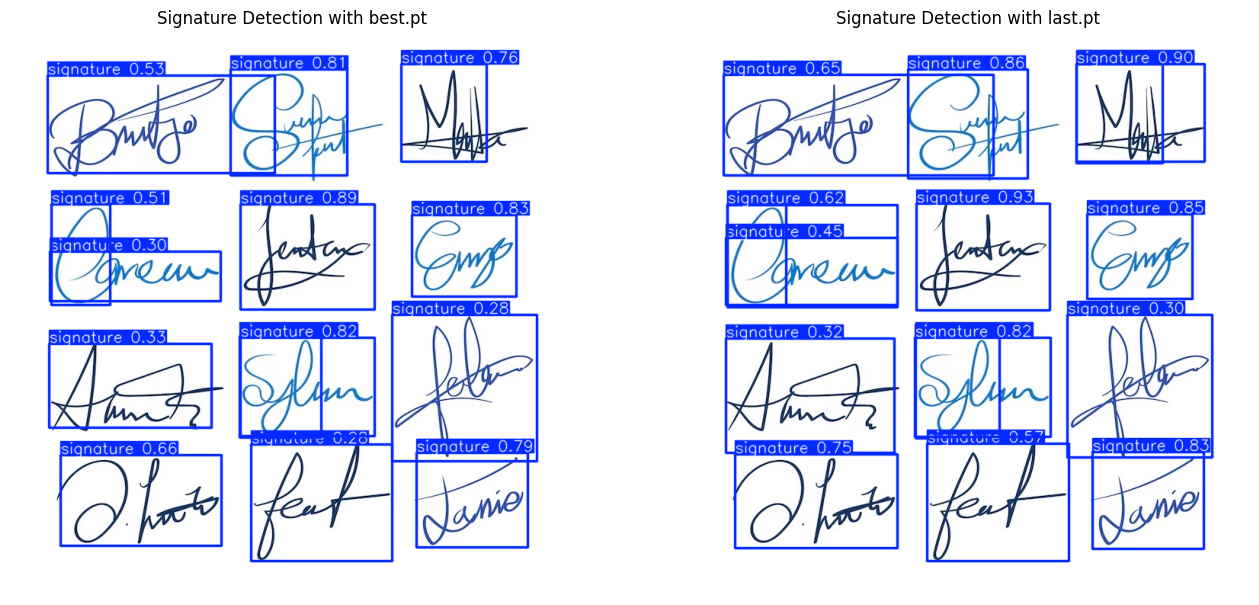

In [15]:
import os

best_model = YOLO("runs/detect/train/weights/best.pt")
last_model = YOLO("runs/detect/train/weights/last.pt")

signature_img_path = os.path.join(image_dir, 'Signatures.jpg')

best_res = best_model(signature_img_path)[0]
last_res = last_model(signature_img_path)[0]

img_best = best_res.plot()
img_last = last_res.plot()

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(cv2.cvtColor(img_best, cv2.COLOR_BGR2RGB))
axes[0].set_title("Signature Detection with best.pt")
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(img_last, cv2.COLOR_BGR2RGB))
axes[1].set_title("Signature Detection with last.pt")
axes[1].axis('off')

plt.show()

---
### Conclusions

---

After fine-tuning the YOLO11n model, the custom training resolved the initial challenge where handwritten signatures were completely missed. The model is now capable of correctly detecting and drawing bounding boxes to isolate signatures in the provided document.

The qualitative side-by-side comparison between `best.pt` and `last.pt` visibly contrasts the model's peak validation precision against its final training iteration state prior to convergence.

---

## References

---

1. Ultralytics Documentation.  
   YOLO11 Object Detection, Fine-tuning, and Validations.  
   https://docs.ultralytics.com/

2. PyTorch Documentation.  
   Tensors and deep learning modules.  
   https://pytorch.org/docs/stable/

3. Matplotlib Documentation.  
   Plotting graphs using matplotlib.pyplot.  
   https://matplotlib.org/stable/contents.html

4. OpenCV Documentation.  
   Image processing utilities.  
   https://docs.opencv.org/